# Airline passenger satisfaction

---

### Executive summary

This notebook develops a **supervised classification** pipeline on airline survey data to predict **passenger satisfaction** (`satisfied` vs `neutral or dissatisfied`). The workflow combines **exploratory data analysis (EDA)**, **class-aware cleaning**, **numeric encoding**, a **stratified three-way split**, and comparison of **deep learning (Keras ANN)** vs **Random Forest** and **XGBoost**.

In the **last full run captured below**, holdout **test accuracy** was approximately:

| Model | Role | Test accuracy (approx.) |
| :-- | :-- | :-- |
| **ANN** | Dense baseline | **95.5%** |
| **ANN2** | Alternate dense architecture | **95.8%** |
| **Random Forest** | 200 trees, parallel | **95.8%** |
| **XGBoost** | Boosted trees | **~95.9%** (highest in this run) |

Macro **F1 / precision / recall** in the printed classification reports sit around **0.95–0.96**, indicating strong performance on both majority and minority classes at this sample size.

---

### Objectives

1. **Profile** the raw table: schema, missing values, duplicates, and target balance.
2. **Explore** ratings, delays, and demographics with summaries, box plots, and a **correlation heatmap**.
3. **Prepare** a numeric design matrix with **label encoding** and consistent dtypes.
4. **Train** multiple model families on the **same** train/validation/test split with **standardized** inputs where required.
5. **Select** the best model on the **held-out test set** and **export** pickles for deployment (e.g. Streamlit `app.py`).

---

### How to read this document

Run cells **sequentially from top to bottom**. Markdown sections introduce *intent* and *interpretation*; code cells implement the pipeline. Figures and metrics printed under code cells reflect the last execution stored in this file.



In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

try:
    import missingno as msno
    MISSINGNO_AVAILABLE = True
except Exception:
    MISSINGNO_AVAILABLE = False

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
df=pd.read_csv(r"C:\Users\Adham\Downloads\airline_flask_v2\airline satisfaction project\Dataset\data.csv")


In [5]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,is_train
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,1
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,1
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied,1
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,1
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied,1


In [6]:
df.drop(columns=['id','Unnamed: 0','is_train'], inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    1298

### 1. Data quality checks

Before modeling, we verify **structural integrity**:

- **Completeness** — proportion of missing values per column.
- **Uniqueness** — duplicate row counts (residual survey duplication).
- **Consistency** — dtypes and plausible ranges for delays and ordinal ratings.

Rows with missing values are **dropped** after quantifying impact, so later statistics and models operate on a **fully observed** design matrix. If a future revision prefers imputation, replace the drop step and document the imputer in this section.



#### 1.1 Missing values

The next cell reports **missing rate per column** (as a fraction of all rows). High missingness on a single feature may justify dropping the feature or using domain-specific imputation; sparse scattered missingness is often listwise-deleted for tree models and neural nets, as implemented here.



In [8]:
df.isnull().sum()/len(df)

Gender                               0.000000
Customer Type                        0.000000
Age                                  0.000000
Type of Travel                       0.000000
Class                                0.000000
Flight Distance                      0.000000
Inflight wifi service                0.000000
Departure/Arrival time convenient    0.000000
Ease of Online booking               0.000000
Gate location                        0.000000
Food and drink                       0.000000
Online boarding                      0.000000
Seat comfort                         0.000000
Inflight entertainment               0.000000
On-board service                     0.000000
Leg room service                     0.000000
Baggage handling                     0.000000
Checkin service                      0.000000
Inflight service                     0.000000
Cleanliness                          0.000000
Departure Delay in Minutes           0.000000
Arrival Delay in Minutes          

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()/len(df)

Gender                               0.0
Customer Type                        0.0
Age                                  0.0
Type of Travel                       0.0
Class                                0.0
Flight Distance                      0.0
Inflight wifi service                0.0
Departure/Arrival time convenient    0.0
Ease of Online booking               0.0
Gate location                        0.0
Food and drink                       0.0
Online boarding                      0.0
Seat comfort                         0.0
Inflight entertainment               0.0
On-board service                     0.0
Leg room service                     0.0
Baggage handling                     0.0
Checkin service                      0.0
Inflight service                     0.0
Cleanliness                          0.0
Departure Delay in Minutes           0.0
Arrival Delay in Minutes             0.0
satisfaction                         0.0
dtype: float64

#### 1.2 Duplicate records

Duplicate **passenger rows** would leak information across train and test if not removed. The following cell counts exact duplicates. A count of **zero** confirms each remaining row is unique in the cleaned frame.



In [11]:
df.duplicated().sum()

np.int64(0)

## 2. Exploratory data analysis (EDA)

This block characterizes **distributions**, **relationships to satisfaction**, **class balance**, and **multicollinearity**:

| Theme | What to look for |
| :-- | :-- |
| **Ordinal ratings** | Skew, ceiling effects, and contrast between satisfied vs not satisfied. |
| **Categorical mix** | Business vs leisure, cabin class, loyalty segments. |
| **Outliers** | Extreme delays or distances; treatment via **IQR** caps/removal. |
| **Correlation** | Redundant service dimensions; informs intuition (not necessarily feature removal in tree models). |

Rate-like fields are temporarily cast to **object** so categorical summaries distinguish them from truly continuous measures such as **age** or **flight distance**.



In [12]:
## convert rate features to categorical
df['Food and drink'] = df['Food and drink'].astype('object')
df['Inflight wifi service'] = df['Inflight wifi service'].astype('object')
df['Ease of Online booking'] = df['Ease of Online booking'].astype('object')
df['Gate location'] = df['Gate location'].astype('object')
df['Online boarding'] = df['Online boarding'].astype('object')
df['Seat comfort'] = df['Seat comfort'].astype('object')
df['Inflight entertainment'] = df['Inflight entertainment'].astype('object')
df['On-board service'] = df['On-board service'].astype('object')
df['Leg room service'] = df['Leg room service'].astype('object')
df['Baggage handling'] = df['Baggage handling'].astype('object')
df['Checkin service'] = df['Checkin service'].astype('object')
df['Inflight service'] = df['Inflight service'].astype('object')
df['Cleanliness'] = df['Cleanliness'].astype('object')
df['Departure/Arrival time convenient'] = df['Departure/Arrival time convenient'].astype('object')

In [13]:
df_categorical = df.select_dtypes(include=['object'])
df_numerical = df.select_dtypes(include=['int64', 'float64'])

In [14]:
df_categorical.describe().T

,count,unique,top,freq
Gender,129487,2,Female,65703
Customer Type,129487,2,Loyal Customer,105773
Type of Travel,129487,2,Business travel,89445
Class,129487,3,Business,61990
Inflight wifi service,129487,6,2,32236
Departure/Arrival time convenient,129487,6,4,31786
Ease of Online booking,129487,6,3,30297
Gate location,129487,6,3,35611
Food and drink,129487,6,4,30477
Online boarding,129487,6,4,38353


Categorical columns found: 19


,feature,n_unique,top_value,top_freq
6,Ease of Online booking,6,3,30297
5,Departure/Arrival time convenient,6,4,31786
4,Inflight wifi service,6,2,32236
17,Cleanliness,6,4,33871
12,On-board service,6,4,38587
13,Leg room service,6,4,35779
7,Gate location,6,3,35611
9,Online boarding,6,4,38353
8,Food and drink,6,4,30477
10,Seat comfort,6,4,39651


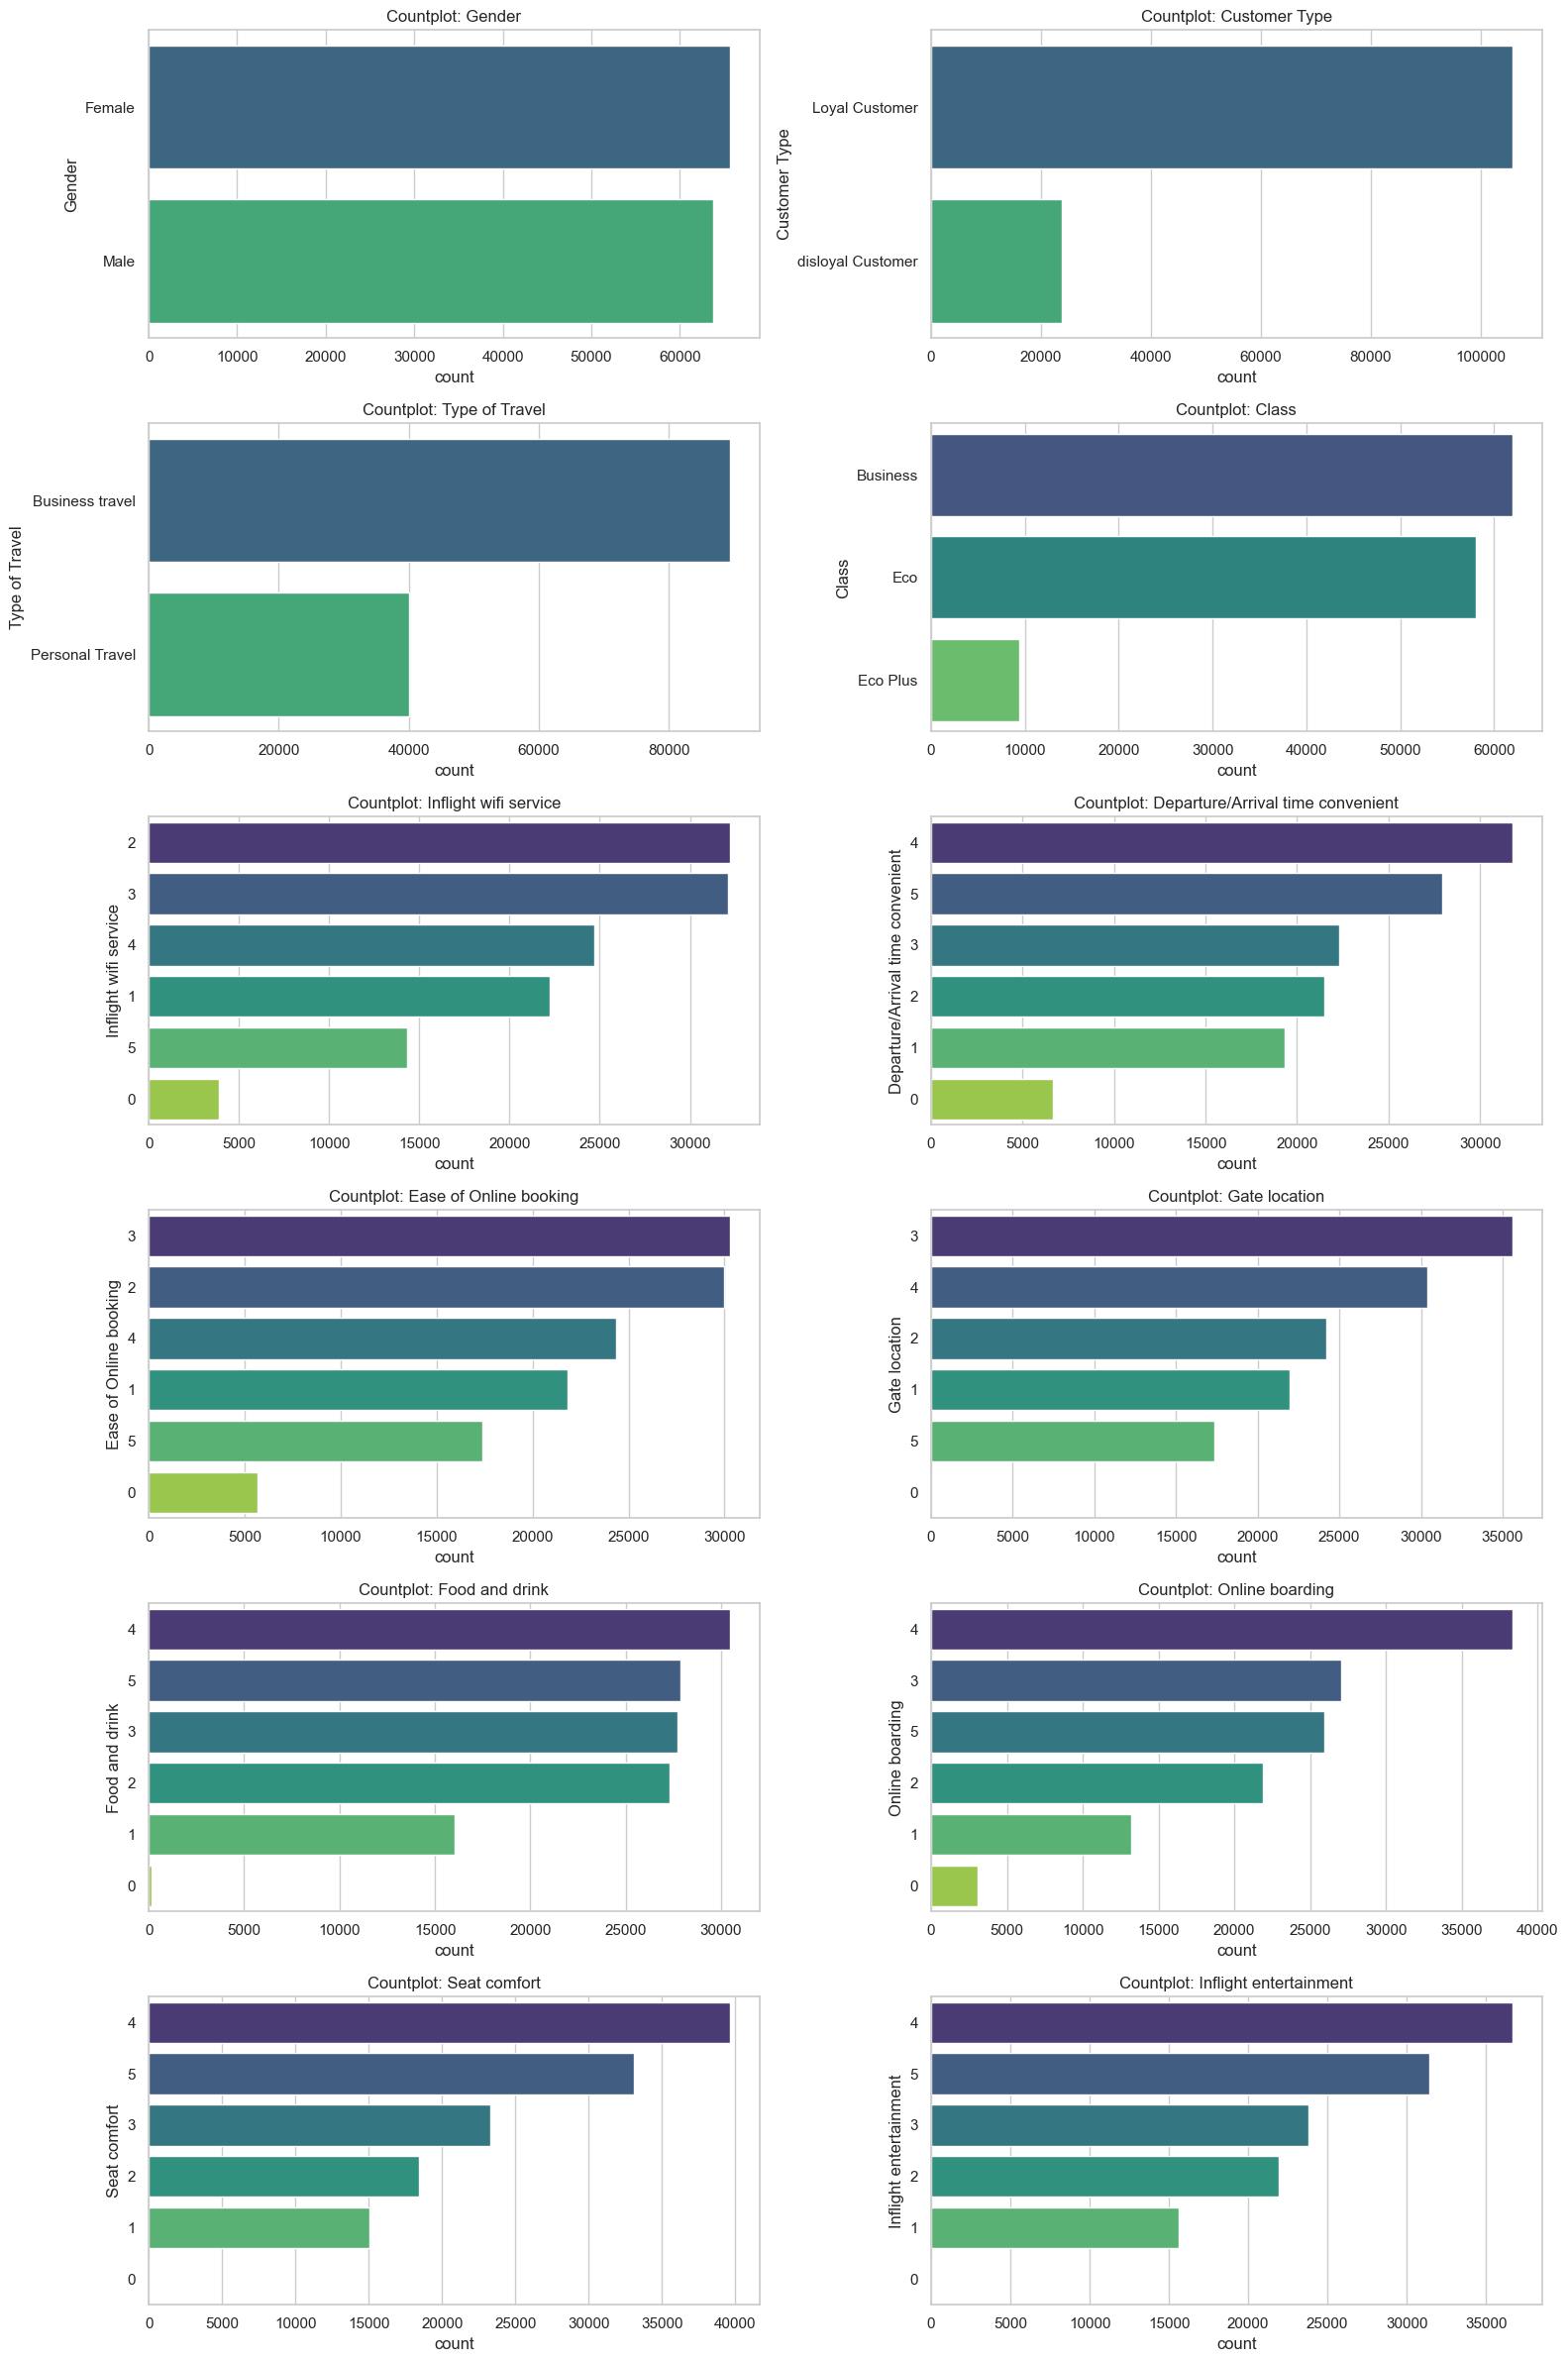

In [15]:
# Categorical feature eda
print(f"Categorical columns found: {len(df_categorical.columns)}")

if len(df_categorical.columns) > 0:
    cat_summary = pd.DataFrame({
        "feature": df_categorical.columns,
        "n_unique": [df_categorical[c].nunique(dropna=False) for c in df_categorical.columns],
        "top_value": [df_categorical[c].mode(dropna=False).iloc[0] if len(df_categorical[c].mode(dropna=False)) > 0 else np.nan for c in df_categorical.columns],
        "top_freq": [df_categorical[c].value_counts(dropna=False).iloc[0] if len(df_categorical[c].value_counts(dropna=False)) > 0 else np.nan for c in df_categorical.columns],
    }).sort_values("n_unique", ascending=False)

    display(cat_summary)

    # Plot top categorical columns with manageable cardinality
    plot_cols = [c for c in df_categorical.columns if df_categorical[c].nunique() <= 20][:12]

    if len(plot_cols) > 0:
        n_cols = 2
        n_rows = int(np.ceil(len(plot_cols) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
        axes = np.array(axes).reshape(-1)

        for i, col in enumerate(plot_cols):
            order = df_categorical[col].value_counts().index
            sns.countplot(data=df_categorical, y=col, order=order, ax=axes[i], palette="viridis")
            axes[i].set_title(f"Countplot: {col}")

        for j in range(i + 1, len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show() 

In [16]:
df_numerical.describe()

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
count,129487.000000,129487.000000,129487.000000,129487.000000
mean,39.428761,1190.210662,14.643385,15.091129
std,15.117597,997.560954,37.932867,38.465650
min,7.000000,31.000000,0.000000,0.000000
25%,27.000000,414.000000,0.000000,0.000000
50%,40.000000,844.000000,0.000000,0.000000
75%,51.000000,1744.000000,12.000000,13.000000
max,85.000000,4983.000000,1592.000000,1584.000000


Numeric columns found: 4


,count,mean,std,min,25%,50%,75%,max
Age,129487.0,39.428761,15.117597,7.0,27.0,40.0,51.0,85.0
Flight Distance,129487.0,1190.210662,997.560954,31.0,414.0,844.0,1744.0,4983.0
Departure Delay in Minutes,129487.0,14.643385,37.932867,0.0,0.0,0.0,12.0,1592.0
Arrival Delay in Minutes,129487.0,15.091129,38.465650,0.0,0.0,0.0,13.0,1584.0


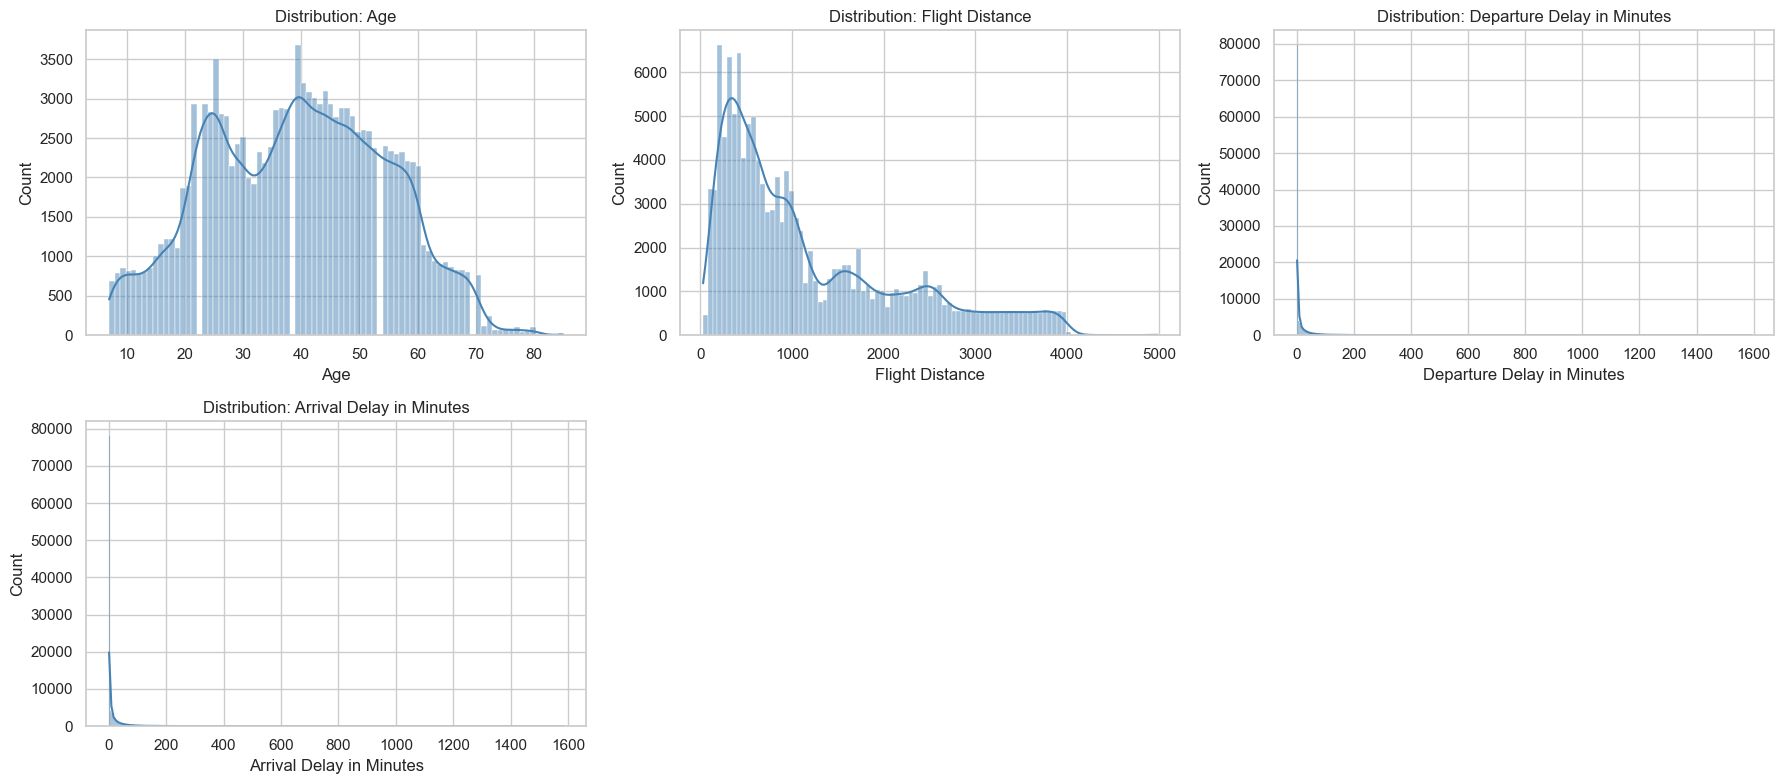

In [17]:
# -------------------------
# Numeric feature distributions
# -------------------------
print(f"Numeric columns found: {len(df_numerical.columns)}")

if len(df_numerical.columns) > 0:
    display(df_numerical.describe().T)

    # Histograms
    n_cols = 3
    n_rows = int(np.ceil(len(df_numerical.columns) / n_cols)) if len(df_numerical.columns) > 0 else 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(df_numerical.columns):
        sns.histplot(df_numerical[col], kde=True, ax=axes[i], color="steelblue")
        axes[i].set_title(f"Distribution: {col}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [18]:
# -------------------------
# plot  Outlier checks (IQR method) for numeric features
# -------------------------
print("Outlier checks using IQR method:")
for col in df_numerical.columns:
    Q1 = df_numerical[col].quantile(0.25)
    Q3 = df_numerical[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_numerical[(df_numerical[col] < lower_bound) | (df_numerical[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")
    



Outlier checks using IQR method:
Age: 0 outliers
Flight Distance: 2847 outliers
Departure Delay in Minutes: 17970 outliers
Arrival Delay in Minutes: 17492 outliers


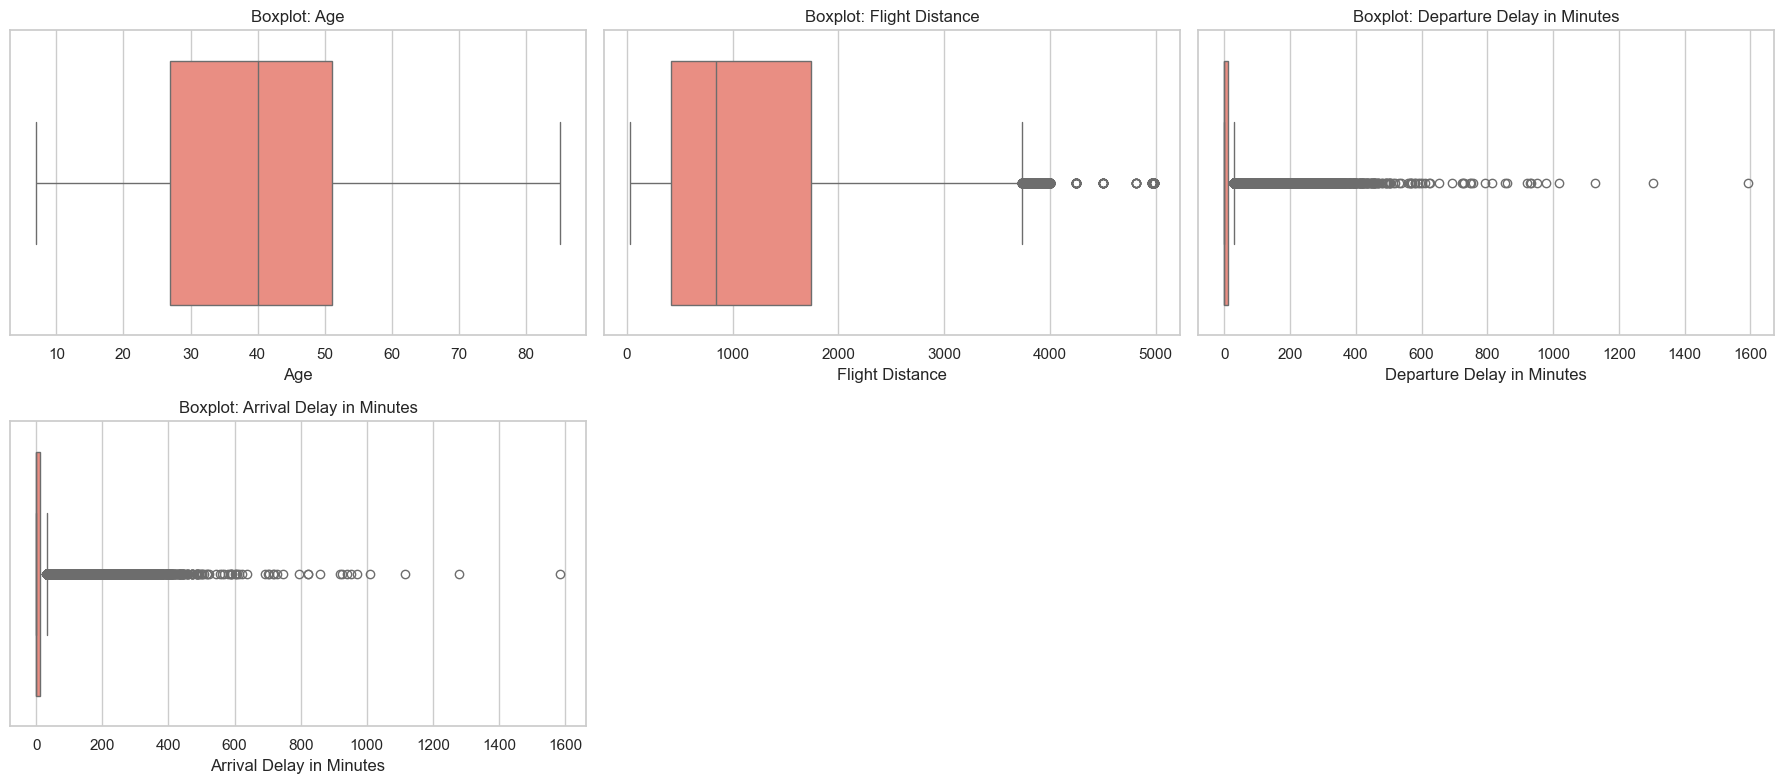

In [19]:
# -------------------------
# plot  Outlier checks (IQR method) for numeric features
# -------------------------
plt.figure(figsize=(18, 4 * n_rows))
for i, col in enumerate(df_numerical.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_numerical[col], color="salmon")
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()    


In [18]:
## remove outliers using IQR method in df
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        

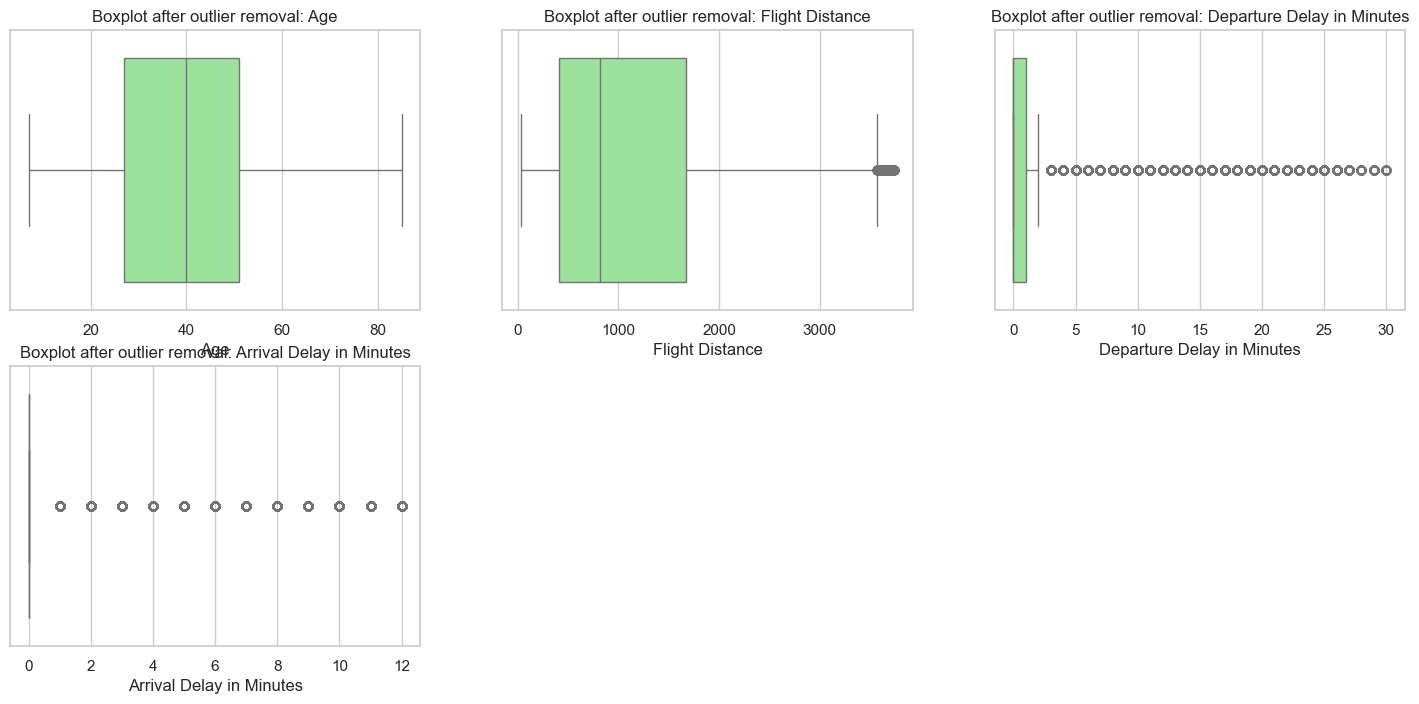

In [19]:
## check box_plot after outlier removal
plt.figure(figsize=(18, 4 * n_rows))
for i, col in enumerate(df_numerical.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(f"Boxplot after outlier removal: {col}")

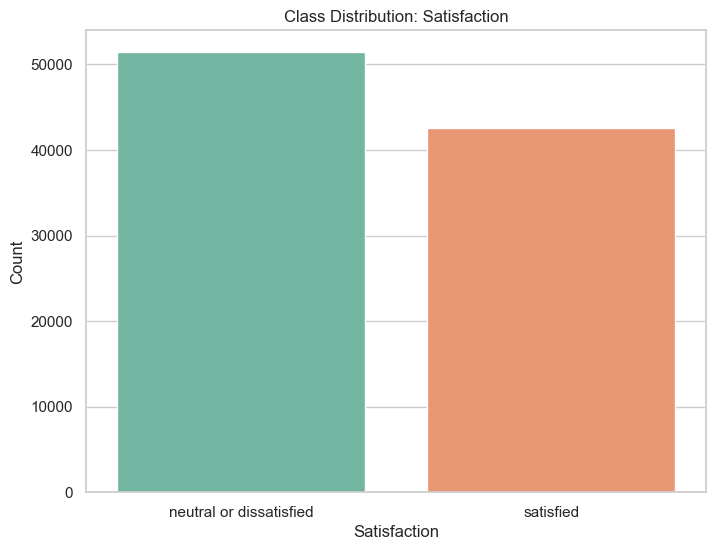

In [20]:
## class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=df['satisfaction'], palette="Set2")
plt.title("Class Distribution: Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Count")
plt.show()

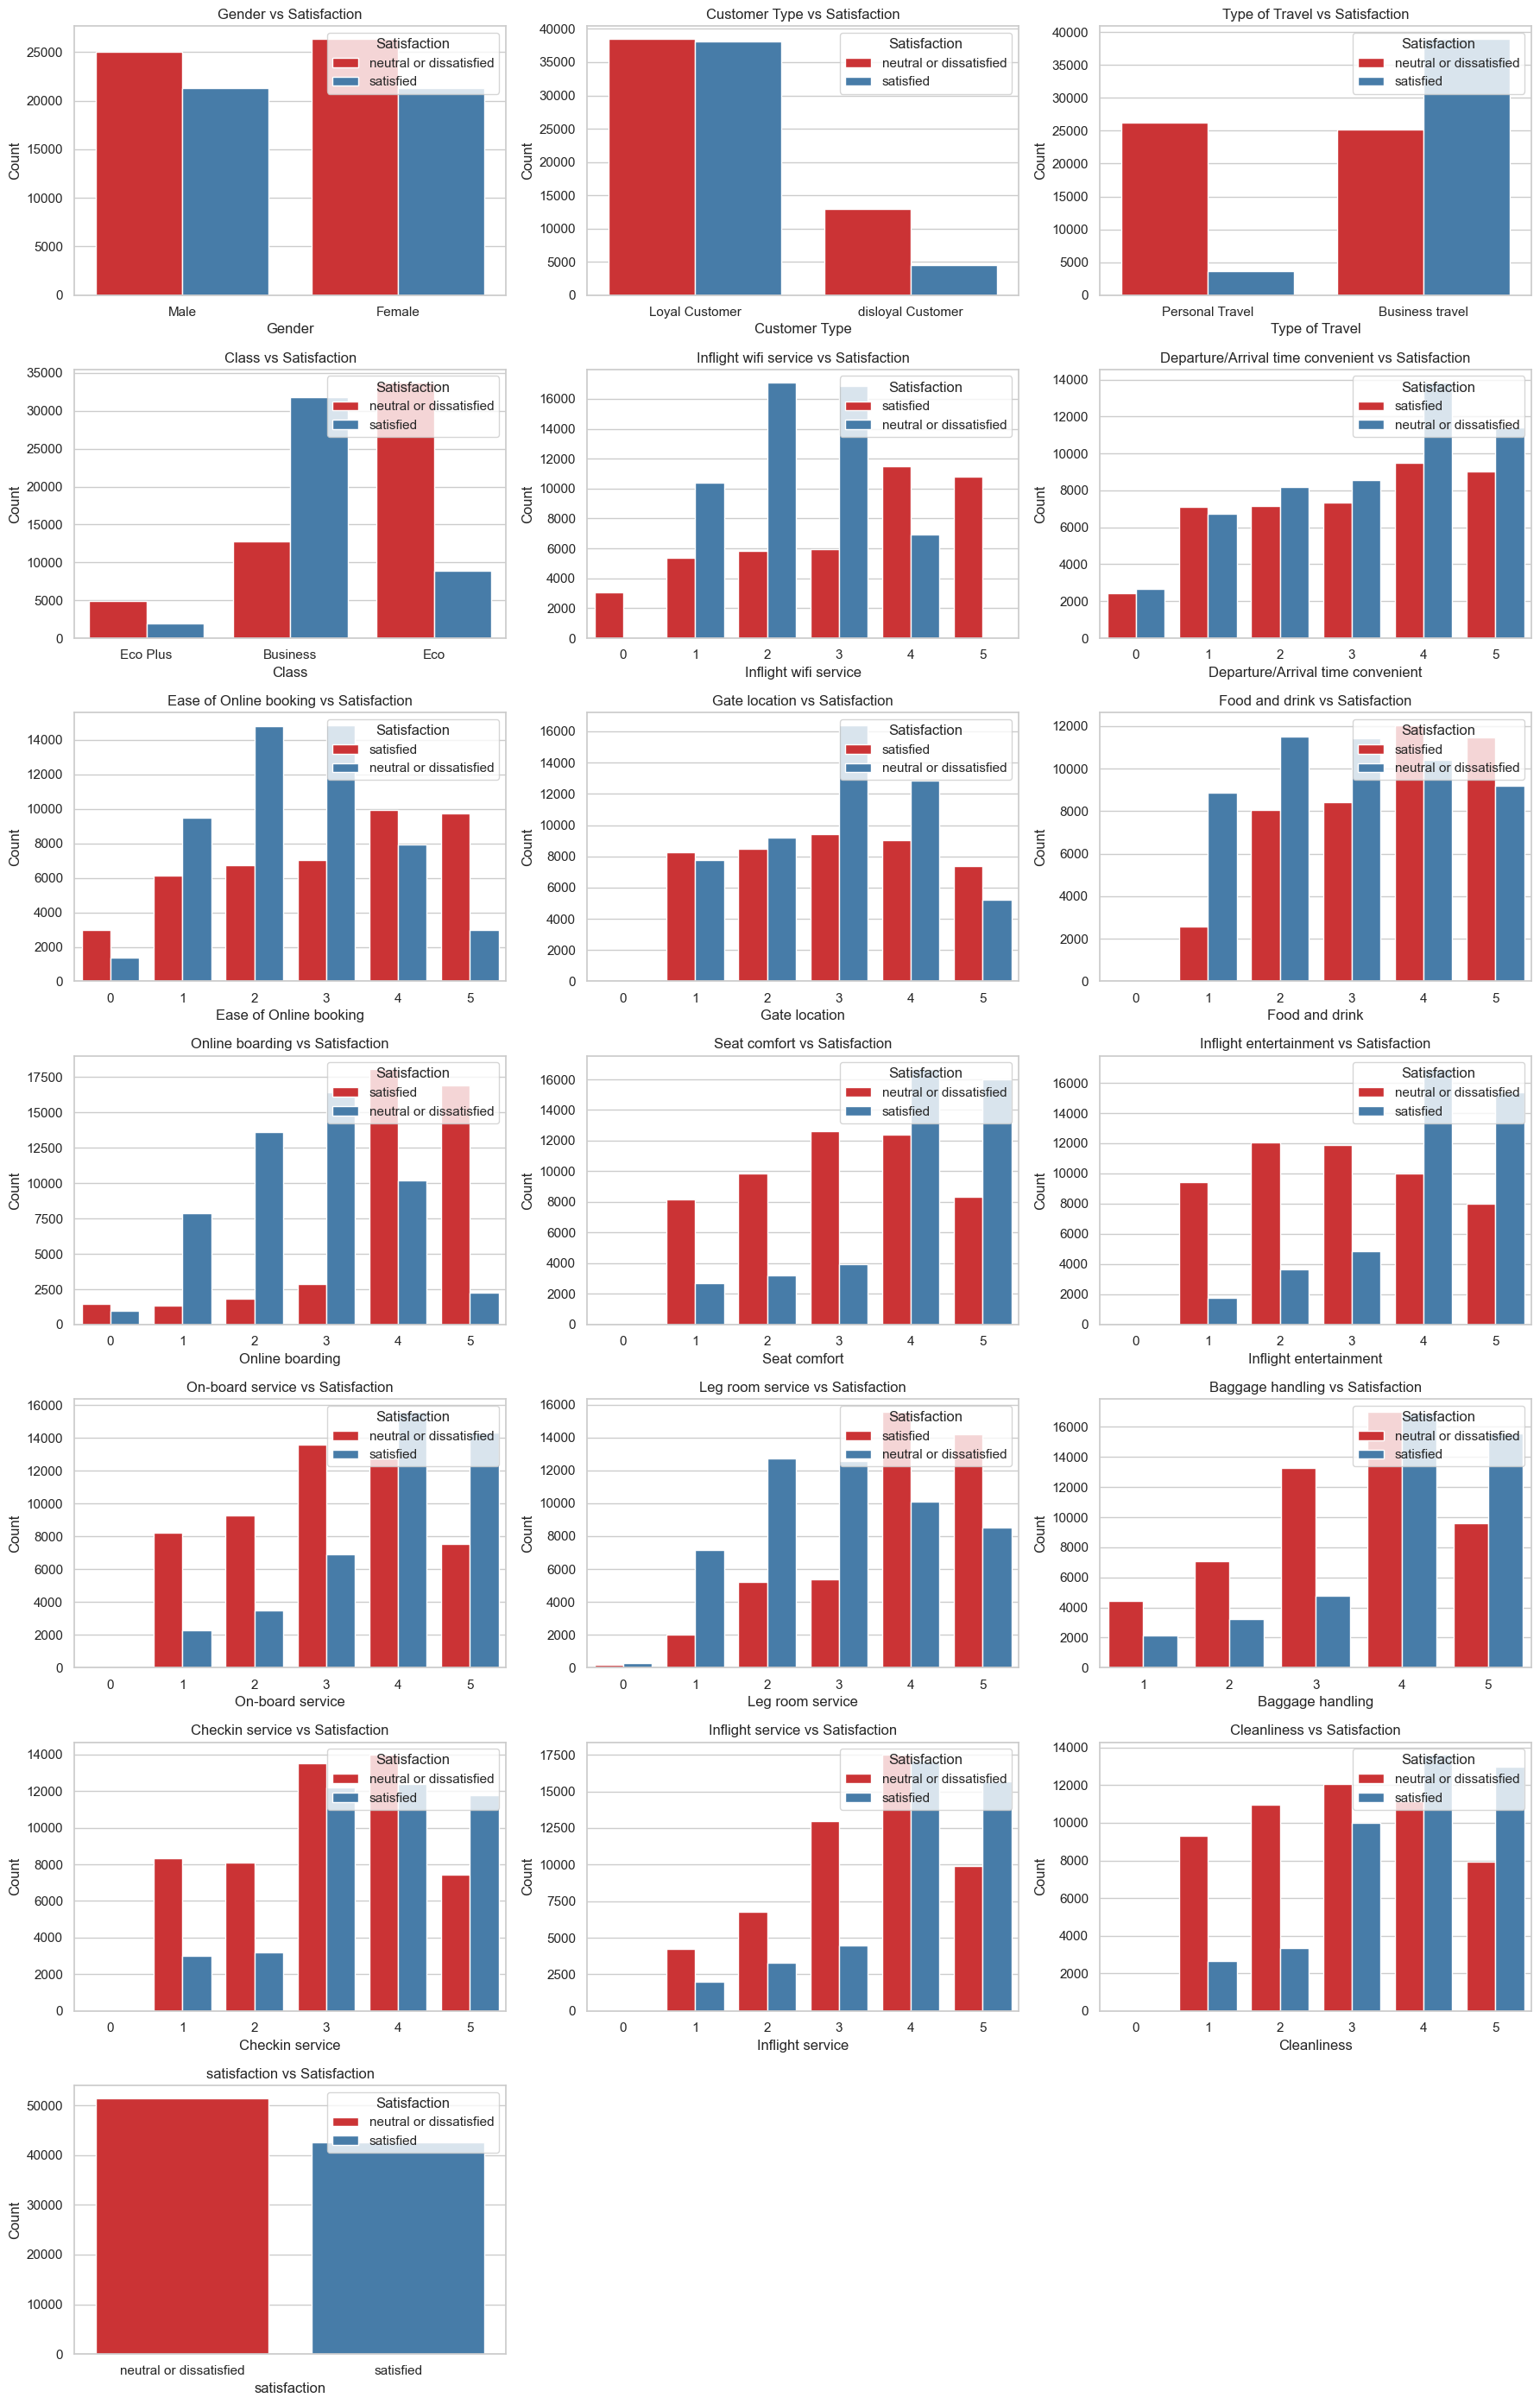

In [22]:
## categorical feature with hue satisfaction
n_cols = 3
n_rows = int(np.ceil(len(df_categorical.columns) / n_cols)) if len(df_categorical.columns) > 0 else 1
plt.figure(figsize=(18, 4 * n_rows))
for i, col in enumerate(df_categorical.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df_categorical, x=col, hue=df['satisfaction'], palette="Set1")
    plt.title(f"{col} vs Satisfaction")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Satisfaction", loc="upper right")
plt.tight_layout()
plt.show()    

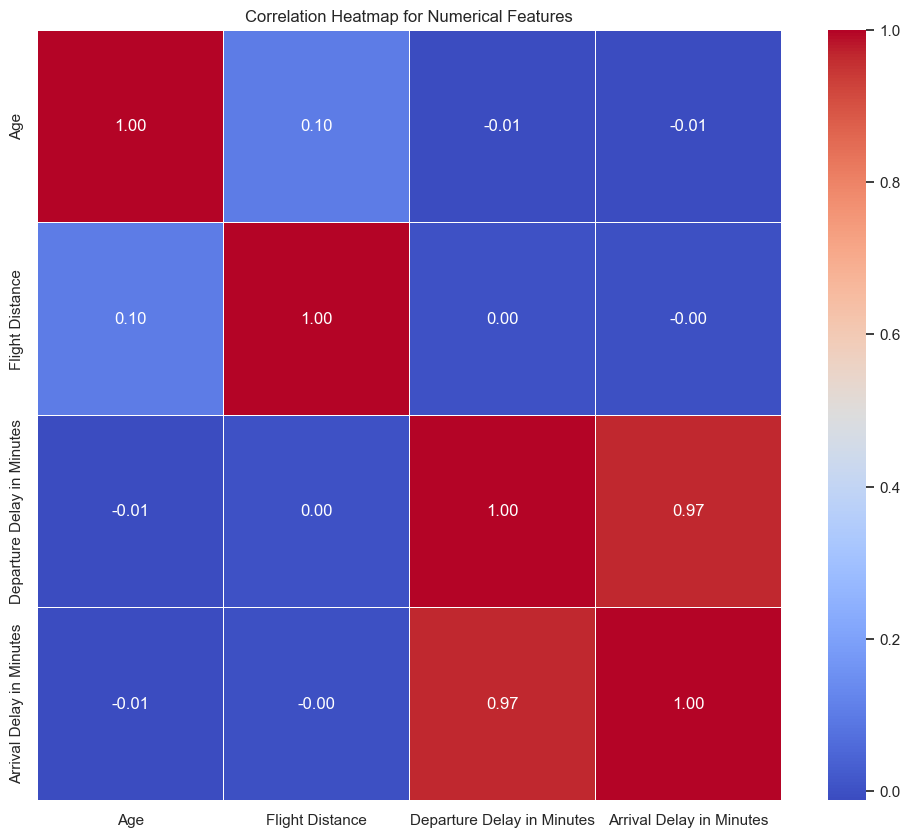

In [ ]:
## plot correlation heatmap for numerical features
plt.figure(figsize=(12, 10))
corr = df_numerical.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Features")
plt.show()

---

### Bridge: from EDA to feature engineering

The preceding visuals summarize **class balance**, **segmentation** (travel type, class, loyalty), **service ratings** broken down by satisfaction, and a **numeric correlation heatmap**.

**Typical takeaways for this dataset:**

- Inflight **service quality** dimensions move together (wifi, seat, entertainment, cleanliness).
- **Operational stressors** (delays) and **cabin/loyalty** structure help separate satisfied vs dissatisfied passengers.
- **Multicollinearity** among service scores is expected; tree ensembles handle redundancy well, while linear-style models would need regularization or selection.

The next section **encodes** categoricals and the target so all estimators consume a single numeric tensor.

---


### 3. Feature encoding

Machine learning implementations here expect **numeric** inputs:

- **Target** — binary mapping: `neutral or dissatisfied` → **0**, `satisfied` → **1**.
- **Gender** — male / female mapped to **0 / 1**.
- **Nominal categories** (`Customer Type`, `Type of Travel`, `Class`) — **sklearn `LabelEncoder`** with **dictionaries** saved for inference-time alignment with the Streamlit app.

After encoding, remaining object columns are cast to **float32** for memory efficiency and Keras compatibility.



In [ ]:
## encode target variable
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

In [ ]:
## encode gender feature
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [ ]:
from sklearn.preprocessing import LabelEncoder
Customer_encoder = LabelEncoder()
Customer_encoder.fit(df['Customer Type'])
df['Customer Type'] = Customer_encoder.transform(df['Customer Type'])
Customer_encoders = dict(zip(Customer_encoder.classes_, Customer_encoder.transform(Customer_encoder.classes_)))
print(Customer_encoders)

{'Loyal Customer': np.int64(0), 'disloyal Customer': np.int64(1)}


In [ ]:
travel_encoder = LabelEncoder()
travel_encoder.fit(df['Type of Travel'])
df['Type of Travel'] = travel_encoder.transform(df['Type of Travel'])
Travel_encoders = dict(zip(travel_encoder.classes_, travel_encoder.transform(travel_encoder.classes_)))
print(Travel_encoders)

{'Business travel': np.int64(0), 'Personal Travel': np.int64(1)}


In [ ]:
class_encoder = LabelEncoder()
class_encoder.fit(df['Class'])
df['Class'] = class_encoder.transform(df['Class'])
Class_encoders = dict(zip(class_encoder.classes_, class_encoder.transform(class_encoder.classes_)))
print(Class_encoders)

{'Business': np.int64(0), 'Eco': np.int64(1), 'Eco Plus': np.int64(2)}


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93996 entries, 1 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             93996 non-null  int64  
 1   Customer Type                      93996 non-null  object 
 2   Age                                93996 non-null  int64  
 3   Type of Travel                     93996 non-null  object 
 4   Class                              93996 non-null  object 
 5   Flight Distance                    93996 non-null  int64  
 6   Inflight wifi service              93996 non-null  object 
 7   Departure/Arrival time convenient  93996 non-null  object 
 8   Ease of Online booking             93996 non-null  object 
 9   Gate location                      93996 non-null  object 
 10  Food and drink                     93996 non-null  object 
 11  Online boarding                    93996 non-null  object 

In [ ]:
## convert object features to float32
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('float32')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93996 entries, 1 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             93996 non-null  int64  
 1   Customer Type                      93996 non-null  int64  
 2   Age                                93996 non-null  int64  
 3   Type of Travel                     93996 non-null  int64  
 4   Class                              93996 non-null  int64  
 5   Flight Distance                    93996 non-null  int64  
 6   Inflight wifi service              93996 non-null  float32
 7   Departure/Arrival time convenient  93996 non-null  float32
 8   Ease of Online booking             93996 non-null  float32
 9   Gate location                      93996 non-null  float32
 10  Food and drink                     93996 non-null  float32
 11  Online boarding                    93996 non-null  float32

### 4. Train / validation / test split

**Features** `X` comprise all columns except `satisfaction`; **labels** `y` are the encoded target.

A **nested split** is used:

1. **Primary holdout** — `test_size=0.2` → unbiased **test** evaluation.
2. **Validation** — `test_size=0.1` *within the training portion* → **early stopping** and monitoring for neural networks without touching the final test set.

`random_state=42` keeps partitions **reproducible** across runs and model comparisons.



In [ ]:
## split data into train and test
from sklearn.model_selection import train_test_split
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42)

print("✅ Preprocessing complete!")
print(f"Train      : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test.shape}")   

✅ Preprocessing complete!
Train      : (67676, 22)
Validation : (7520, 22)
Test       : (18800, 22)


### 5. Deep learning models (ANN) & preprocessing

**`StandardScaler`** is **fit on the training set only** and applied to validation and test — this avoids **information leakage** from held-out data into scale parameters.

Two **feedforward** architectures (**ANN**, **ANN2**) use dense layers, **dropout**, and **`EarlyStopping`** on `val_loss` (`patience=5`, `restore_best_weights=True`). Training curves are plotted via the helper `plot_history`.

> **Interpretation tip:** rising training accuracy with flat or worsening validation accuracy suggests overfitting; early stopping mitigates this by restoring the best weights before divergence.

#### Experimental setup (neural networks)

| Setting | Choice | Rationale |
| :-- | :-- | :-- |
| Input shape | 22 features (after preprocessing) | Matches the engineered matrix minus the target. |
| Callbacks | `EarlyStopping` on `val_loss` | Stop when validation generalization stops improving. |
| Reporting | Test loss & accuracy, `classification_report` | Aligns with classical baselines on the same split. |

**ANN vs ANN2** differ in architecture hyperparameters in code—compare **held-out test metrics**, not only training curves.



In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)
results = {}

from pathlib import Path


def _figures_dir() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "data" / "data.csv").is_file():
            out = base / "figures"
            out.mkdir(parents=True, exist_ok=True)
            return out
    out = cwd / "figures"
    out.mkdir(parents=True, exist_ok=True)
    return out


FIGURES = _figures_dir()

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(FIGURES / f"{title.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()


Epoch 1/50
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8840 - loss: 0.2871 - val_accuracy: 0.9279 - val_loss: 0.1838
Epoch 2/50
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9177 - loss: 0.1980 - val_accuracy: 0.9392 - val_loss: 0.1523
Epoch 3/50
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9282 - loss: 0.1693 - val_accuracy: 0.9414 - val_loss: 0.1359
Epoch 4/50
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9353 - loss: 0.1525 - val_accuracy: 0.9471 - val_loss: 0.1239
Epoch 5/50
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9402 - loss: 0.1417 - val_accuracy: 0.9424 - val_loss: 0.1226
Epoch 6/50
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9422 - loss: 0.1361 - val_accuracy: 0.9497 - val_loss: 0.1153
Epoch 7/50
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9440 - loss: 0.1315 - val_accuracy: 0.9473 - val_loss: 0.1178
Epoch 8/50
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9462 - loss: 0.1269 - 

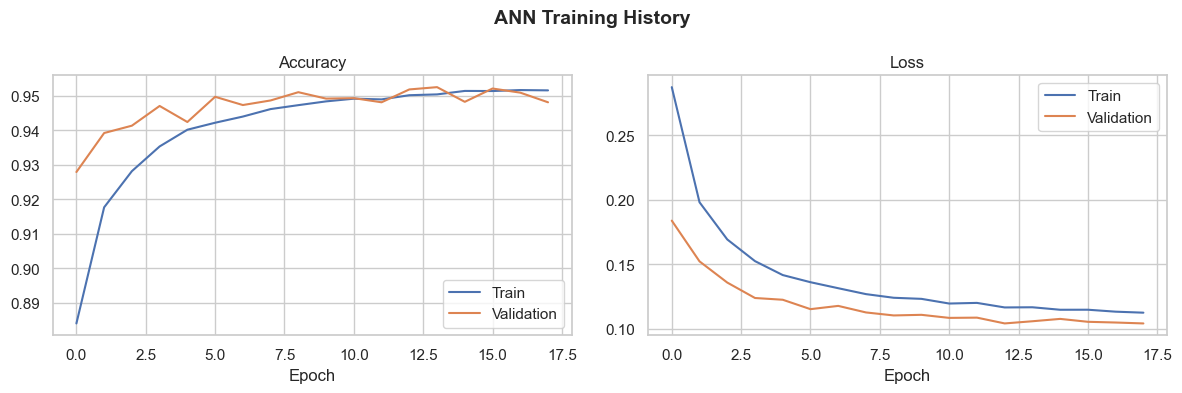

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96     10298
           1       0.98      0.92      0.95      8502

    accuracy                           0.95     18800
   macro avg       0.96      0.95      0.95     18800
weighted avg       0.96      0.95      0.95     18800

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 982us/step
Confusion Matrix:
 [[10104   194]
 [  659  7843]]


In [ ]:
# ANN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(22,)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')  # binary classification
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)
results['ANN'] = model.evaluate(X_test, y_test, verbose=0)
print(f"ANN Test Loss: {results['ANN'][0]:.4f}, Test Accuracy: {results['ANN'][1]:.4f}")
plot_history(history, "ANN Training History")
print("Classification Report:\n", classification_report(y_test, (model.predict(X_test) > 0.5).astype(int)))
print("Confusion Matrix:\n", confusion_matrix(y_test, (model.predict(X_test) > 0.5).astype(int)))

Epoch 1/30
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8849 - loss: 0.2869 - val_accuracy: 0.9237 - val_loss: 0.1842
Epoch 2/30
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9201 - loss: 0.1957 - val_accuracy: 0.9410 - val_loss: 0.1474
Epoch 3/30
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9305 - loss: 0.1649 - val_accuracy: 0.9471 - val_loss: 0.1258
Epoch 4/30
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9395 - loss: 0.1455 - val_accuracy: 0.9505 - val_loss: 0.1187
Epoch 5/30
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9431 - loss: 0.1352 - val_accuracy: 0.9496 - val_loss: 0.1165
Epoch 6/30
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9445 - loss: 0.1305 - val_accuracy: 0.9537 - val_loss: 0.1144
Epoch 7/30
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9463 - loss: 0.1285 - val_accuracy: 0.9531 - val_loss: 0.1119
Epoch 8/30
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9470 - loss: 0.1245 - 

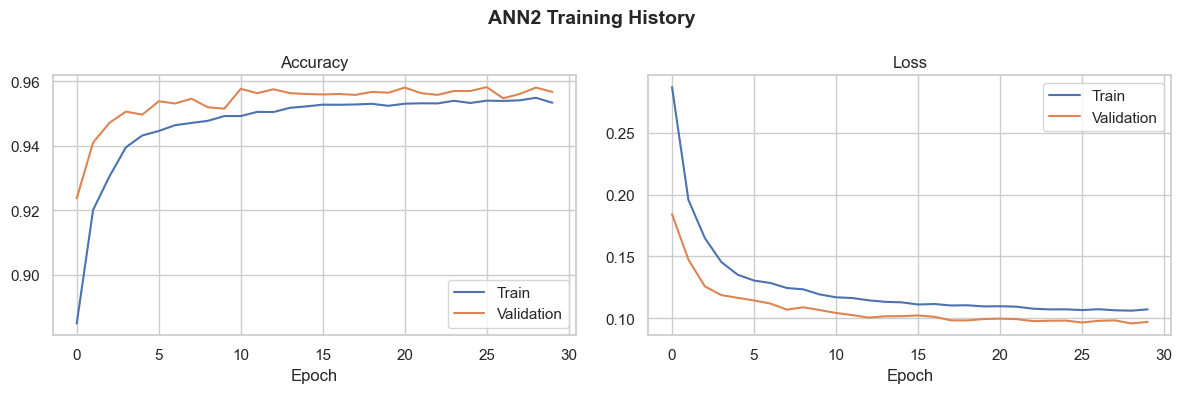

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96     10298
           1       0.97      0.94      0.95      8502

    accuracy                           0.96     18800
   macro avg       0.96      0.96      0.96     18800
weighted avg       0.96      0.96      0.96     18800

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 852us/step
Confusion Matrix:
 [[10055   243]
 [  539  7963]]


In [ ]:
# ANN2 model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_ANN2 = Sequential([
    Dense(64, activation='relu', input_shape=(22,)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')  # binary classification
])
model_ANN2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model_ANN2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    
)
results['ANN2'] = model_ANN2.evaluate(X_test, y_test, verbose=0)
print(f"ANN2 Test Loss: {results['ANN2'][0]:.4f}, Test Accuracy: {results['ANN2'][1]:.4f}")
plot_history(history, "ANN2 Training History")
print("Classification Report:\n", classification_report(y_test, (model_ANN2.predict(X_test) > 0.5).astype(int)))
print("Confusion Matrix:\n", confusion_matrix(y_test, (model_ANN2.predict(X_test) > 0.5).astype(int)))

### 6. Classical baselines: Random Forest & XGBoost

**Tabular** airline data is often well suited to **gradient boosting** and **random forests**:

- **RandomForest** — `n_estimators=200`, full parallelism (`n_jobs=-1`), **bagging** reduces variance.
- **XGBoost** — staged additive trees with **regularization** (`max_depth`, `subsample`, `colsample_by_tree`).

These models consume the **same scaled** `X_train` / `X_test` as the neural baselines here, ensuring a **fair comparison** on identical splits. In this notebook’s last run, **XGBoost achieved the highest test accuracy (~95.9%)**, with Random Forest and ANN2 close behind—differences are small, so **latency, explainability, and ops** should drive the final production choice.



In [ ]:
## random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
results['Random Forest'] = rf_model.score(X_test, y_test)
print(f"Random Forest Test Accuracy: {results['Random Forest']:.4f}")
print("Classification Report:\n", classification_report(y_test, rf_model.predict(X_test)))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_model.predict(X_test)))

Random Forest Test Accuracy: 0.9579
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96     10298
           1       0.97      0.93      0.95      8502

    accuracy                           0.96     18800
   macro avg       0.96      0.96      0.96     18800
weighted avg       0.96      0.96      0.96     18800

Confusion Matrix:
 [[10059   239]
 [  553  7949]]


In [ ]:
## Xgboost model
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
results['XGBoost'] = xgb_model.score(X_test, y_test)
print(f"XGBoost Test Accuracy: {results['XGBoost']:.4f}")
print("Classification Report:\n", classification_report(y_test, xgb_model.predict(X_test)))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_model.predict(X_test)))

XGBoost Test Accuracy: 0.9593
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96     10298
           1       0.97      0.94      0.95      8502

    accuracy                           0.96     18800
   macro avg       0.96      0.96      0.96     18800
weighted avg       0.96      0.96      0.96     18800

Confusion Matrix:
 [[10069   229]
 [  537  7965]]


### 7. Model leaderboard & selection

The following cells consolidate **test accuracy** for **ANN**, **ANN2**, **Random Forest**, and **XGBoost**, choose `best_model_name` by the maximum score, and (for tree models) reuse **probability or label** predictions as implemented in code.

#### Results snapshot (last executed run)

| Rank (approx.) | Model | Test accuracy |
| :--: | :-- | :--: |
| 1 | **XGBoost** | **~95.9%** |
| 2 | **ANN2** | **~95.8%** |
| 3 | **Random Forest** | **~95.8%** |
| 4 | **ANN** | **~95.5%** |

Margins are **under one percentage point**—for production, weigh **inference cost**, **interpretability** (trees vs nets), and **stability** across random seeds, not accuracy alone.

The bar chart cell supports slide decks; printed **`classification_report`** gives **per-class** precision and recall for stakeholder-ready narratives.



In [ ]:
results['ANN'] = results["ANN"][1]
results['ANN2'] = results["ANN2"][1]



Model                  Test Accuracy
ANN                           95.46%
ANN2                          95.84%
Random Forest                 95.79%
XGBoost                       95.93%

🏆 Best: XGBoost (95.93%)


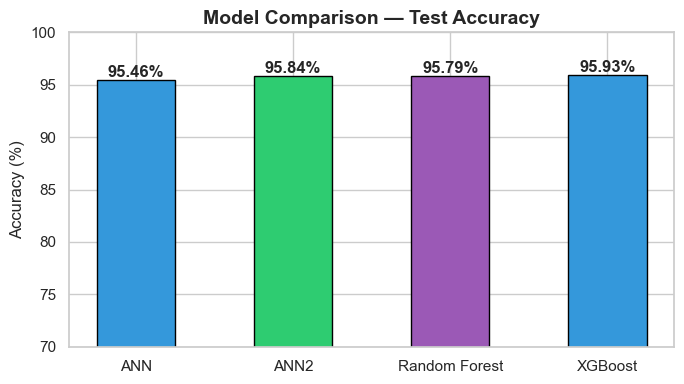

In [ ]:
from pathlib import Path


def _figures_dir() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "data" / "data.csv").is_file():
            out = base / "figures"
            out.mkdir(parents=True, exist_ok=True)
            return out
    out = cwd / "figures"
    out.mkdir(parents=True, exist_ok=True)
    return out


FIGURES = _figures_dir()

print('=' * 45)
print(f'{"Model":<20} {"Test Accuracy":>15}')
print('=' * 45)
for name, acc in results.items():
    print(f'{name:<20} {acc*100:>14.2f}%')
print('=' * 45)

best_model_name = max(results, key=results.get)
print(f'\n🏆 Best: {best_model_name} ({results[best_model_name]*100:.2f}%)')

plt.figure(figsize=(7, 4))
colors = ['#3498db', '#2ecc71', '#9b59b6']
bars = plt.bar(results.keys(), [v*100 for v in results.values()],
               color=colors, edgecolor='black', width=0.5)
plt.ylim(70, 100)
plt.title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val*100:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'model_comparison.png', dpi=150)
plt.show()


📊 Classification Report — XGBoost
              precision    recall  f1-score   support

    Negative       0.95      0.98      0.96     10298
    Positive       0.97      0.94      0.95      8502

    accuracy                           0.96     18800
   macro avg       0.96      0.96      0.96     18800
weighted avg       0.96      0.96      0.96     18800



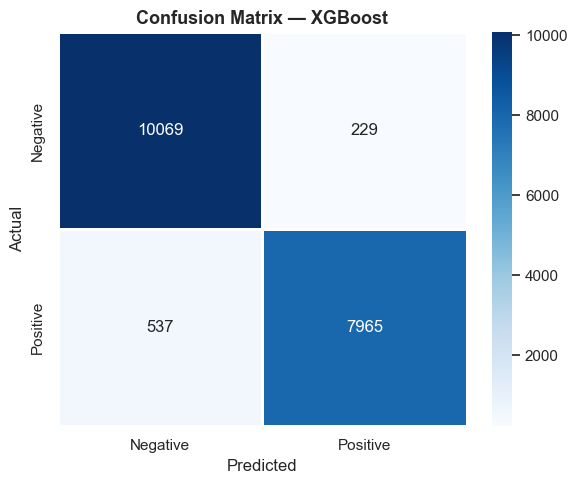

In [ ]:
from pathlib import Path


def _figures_dir() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "data" / "data.csv").is_file():
            out = base / "figures"
            out.mkdir(parents=True, exist_ok=True)
            return out
    out = cwd / "figures"
    out.mkdir(parents=True, exist_ok=True)
    return out


FIGURES = _figures_dir()

best={
    'ANN': model,
    'ANN2': model_ANN2,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}[best_model_name]

if best_model_name in ['ANN', 'ANN2']:
    y_pred = (best.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
else:
    y_pred = best.predict(X_test)

print(f'📊 Classification Report — {best_model_name}')
print('=' * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=1, linecolor='white')
plt.title(f'Confusion Matrix — {best_model_name}',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(FIGURES / 'confusion_matrix.png', dpi=150)
plt.show()


### 8. Artifact export & deployment

The final cell persists:

| Artifact | Purpose |
| :-- | :-- |
| `best_model.pkl` | Winning estimator (architecture varies by winner). |
| `input_scaler.pkl` | `StandardScaler` for online feature scaling. |
| `class_encoder.pkl`, `customer_encoder.pkl`, `travel_type_encoder.pkl` | **Mappings** from raw labels to model codes. |

Place these files in the project **`artifacts/`** directory next to **`app.py`**. The Streamlit app loads them with **relative paths**, applies the same encoding and scaling, and serves predictions without retraining.

> Re-run the save cell **after** training completes so `best` and `best_model_name` are defined in the kernel session.



### 9. Conclusion & next steps

This notebook demonstrates a **full ML lifecycle** on airline satisfaction data, from **data quality** through **multi-model benchmarking** (∼**95.5%–95.9%** test accuracy in the captured run).

**Suggested extensions:**

- **Calibration** — reliability curves or Brier score if probabilities drive business thresholds.
- **Error analysis** — inspect false negatives/positives by cabin and route length.
- **Feature importance** — SHAP for XGBoost/Random Forest to explain drivers of dissatisfaction.
- **MLOps** — version datasets and pickles, automate retraining, and monitor drift in production.

---
*End of notebook narrative — ensure all code cells above have been executed in order before relying on saved outputs.*
